<a href="https://colab.research.google.com/github/sanjayanand595/Computer-Network/blob/main/machine_learning_ita0607.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
# FIND-S Algorithm Implementation

import numpy as np
import pandas as pd

# Step 1: Create training dataset
data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

# Convert to DataFrame
columns = ['Sky', 'Temp', 'Humidity', 'Wind', 'Water', 'Forecast', 'EnjoySport']
df = pd.DataFrame(data, columns=columns)

print("Training Dataset:\n")
print(df)
print("\n")

# Step 2: Separate features and target
X = np.array(df.iloc[:, :-1])
y = np.array(df.iloc[:, -1])

# Step 3: Initialize hypothesis with most specific values
hypothesis = X[0].copy()

print("Initial Hypothesis:")
print(hypothesis)
print("\n")

# Step 4: Apply Find-S algorithm
for i in range(len(X)):
    if y[i] == "Yes":   # Consider only positive examples
        for j in range(len(hypothesis)):
            if hypothesis[j] != X[i][j]:
                hypothesis[j] = "?"  # Generalize
            else:
                hypothesis[j] = hypothesis[j]

    print(f"Step {i+1} Hypothesis: {hypothesis}")

print("\nFinal Most Specific Hypothesis:")
print(hypothesis)

Training Dataset:

     Sky  Temp Humidity    Wind Water Forecast EnjoySport
0  Sunny  Warm   Normal  Strong  Warm     Same        Yes
1  Sunny  Warm     High  Strong  Warm     Same        Yes
2  Rainy  Cold     High  Strong  Warm   Change         No
3  Sunny  Warm     High  Strong  Cool   Change        Yes


Initial Hypothesis:
['Sunny' 'Warm' 'Normal' 'Strong' 'Warm' 'Same']


Step 1 Hypothesis: ['Sunny' 'Warm' 'Normal' 'Strong' 'Warm' 'Same']
Step 2 Hypothesis: ['Sunny' 'Warm' '?' 'Strong' 'Warm' 'Same']
Step 3 Hypothesis: ['Sunny' 'Warm' '?' 'Strong' 'Warm' 'Same']
Step 4 Hypothesis: ['Sunny' 'Warm' '?' 'Strong' '?' '?']

Final Most Specific Hypothesis:
['Sunny' 'Warm' '?' 'Strong' '?' '?']


In [ ]:
# Candidate-Elimination Algorithm Implementation

import pandas as pd
import numpy as np

# Upload CSV file in Colab
from google.colab import files
uploaded = files.upload()

# Read CSV file
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Training Data:\n")
print(data)

# Separate features and target
concepts = np.array(data.iloc[:, :-1])
target = np.array(data.iloc[:, -1])

# Function to initialize S and G
def candidate_elimination(concepts, target):

    num_attributes = concepts.shape[1]

    # Initialize S and G
    S = ['Ø'] * num_attributes
    G = [['?'] * num_attributes]

    print("\nInitial Specific Boundary S:", S)
    print("Initial General Boundary G:", G)

    for i, instance in enumerate(concepts):

        if target[i] == "Yes":  # Positive Example

            # Remove hypotheses from G inconsistent with positive example
            G = [g for g in G if all(g[j] == '?' or g[j] == instance[j] for j in range(num_attributes))]

            # Update S
            for j in range(num_attributes):
                if S[j] == 'Ø':
                    S[j] = instance[j]
                elif S[j] != instance[j]:
                    S[j] = '?'

        elif target[i] == "No":  # Negative Example

            new_G = []

            for g in G:
                if all(g[j] == '?' or g[j] == instance[j] for j in range(num_attributes)):

                    for j in range(num_attributes):
                        if g[j] == '?':
                            if S[j] != '?':
                                new_hypothesis = g.copy()
                                new_hypothesis[j] = S[j]
                                new_G.append(new_hypothesis)
                else:
                    new_G.append(g)

            G = new_G

        print(f"\nAfter Example {i+1}:")
        print("S:", S)
        print("G:", G)

    return S, G


# Run Candidate-Elimination
S_final, G_final = candidate_elimination(concepts, target)

print("\n==============================")
print("Final Specific Boundary S:", S_final)
print("Final General Boundary G:", G_final)
print("==============================")

Saving training_data.csv to training_data.csv
Training Data:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Initial Specific Boundary S: ['Ø', 'Ø', 'Ø', 'Ø', 'Ø', 'Ø']
Initial General Boundary G: [['?', '?', '?', '?', '?', '?']]

After Example 1:
S: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
G: [['?', '?', '?', '?', '?', '?']]

After Example 2:
S: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G: [['?', '?', '?', '?', '?', '?']]

After Example 3:
S: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
G: [['Sunny', '?', '?', '?', '?', '?'], ['?', 'Warm', '?', '?', '?', '?'], ['?', '?', '?', 'Strong', '?', '?'], ['?', '?', '?', '?', 'Warm', '?'], ['?', '?', '?', '?', '?', 'Same']]

After Example 4:
S: ['Sunny', 'Warm', '?', 'St

In [ ]:
import pandas as pd
import numpy as np
import math

# Step 1: Create Dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                    'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
             'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes',
                   'No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)
print("Training Dataset:\n")
print(df)


# Step 2: Calculate Entropy
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    ent = 0
    for i in range(len(elements)):
        p = counts[i] / np.sum(counts)
        ent -= p * math.log2(p)
    return ent


# Step 3: Calculate Information Gain
def info_gain(data, split_attribute, target_name="PlayTennis"):
    total_entropy = entropy(data[target_name])

    vals, counts = np.unique(data[split_attribute], return_counts=True)
    weighted_entropy = 0

    for i in range(len(vals)):
        subset = data[data[split_attribute] == vals[i]]
        weighted_entropy += (counts[i]/np.sum(counts)) * entropy(subset[target_name])

    return total_entropy - weighted_entropy


# Step 4: Build ID3 Decision Tree
def ID3(data, originaldata, features, target_name="PlayTennis", parent_node_class=None):

    if len(np.unique(data[target_name])) <= 1:
        return np.unique(data[target_name])[0]

    elif len(data)==0:
        return np.unique(originaldata[target_name])[np.argmax(
            np.unique(originaldata[target_name], return_counts=True)[1])]

    elif len(features) == 0:
        return parent_node_class

    else:
        parent_node_class = np.unique(data[target_name])[
            np.argmax(np.unique(data[target_name], return_counts=True)[1])]

        item_values = [info_gain(data, feature, target_name) for feature in features]
        best_feature_index = np.argmax(item_values)
        best_feature = features[best_feature_index]

        tree = {best_feature:{}}

        features = [i for i in features if i != best_feature]

        for value in np.unique(data[best_feature]):
            sub_data = data[data[best_feature] == value]
            subtree = ID3(sub_data, df, features, target_name, parent_node_class)
            tree[best_feature][value] = subtree

        return tree


# Build Tree
features = df.columns[:-1]
decision_tree = ID3(df, df, features)

print("\nGenerated Decision Tree:\n")
print(decision_tree)


# Step 5: Classify New Sample
def classify(query, tree, default="Yes"):
    for key in query.keys():
        if key in tree:
            try:
                result = tree[key][query[key]]
            except:
                return default
            result = tree[key][query[key]]
            if isinstance(result, dict):
                return classify(query, result)
            else:
                return result

# New Sample
new_sample = {
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}

prediction = classify(new_sample, decision_tree)

print("\nNew Sample:", new_sample)
print("Predicted Class:", prediction)

Training Dataset:

     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No

Generated Decision Tree:

{'Outlook': {'Overcast': 'Yes', 'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}}, 'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}

New Sample: {'Outl

In [ ]:
# Heuristic Search for Decision Tree Splitting
# Using Information Gain as Heuristic

import pandas as pd
import numpy as np
import math

# -----------------------------
# Step 1: Create Dataset
# -----------------------------
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                    'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
             'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes',
                   'No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

print("Training Dataset:\n")
print(df)

# -----------------------------
# Step 2: Entropy Function
# -----------------------------
def entropy(target):
    values, counts = np.unique(target, return_counts=True)
    ent = 0
    for i in range(len(values)):
        p = counts[i] / np.sum(counts)
        ent -= p * math.log2(p)
    return ent


# -----------------------------
# Step 3: Heuristic Function (Information Gain)
# -----------------------------
def information_gain(data, attribute, target="PlayTennis"):
    total_entropy = entropy(data[target])

    values, counts = np.unique(data[attribute], return_counts=True)
    weighted_entropy = 0

    for i in range(len(values)):
        subset = data[data[attribute] == values[i]]
        weighted_entropy += (counts[i] / np.sum(counts)) * entropy(subset[target])

    return total_entropy - weighted_entropy


# -----------------------------
# Step 4: Heuristic Search Split Selection
# -----------------------------
def best_split(data, features, target="PlayTennis"):
    gains = {}
    for feature in features:
        gains[feature] = information_gain(data, feature, target)

    print("\nHeuristic Values (Information Gain):")
    for k, v in gains.items():
        print(f"{k} : {round(v,4)}")

    best_feature = max(gains, key=gains.get)
    print("Best Attribute Selected (Heuristic Search):", best_feature)

    return best_feature


# -----------------------------
# Step 5: Build Decision Tree using Heuristic
# -----------------------------
def build_tree(data, features, target="PlayTennis"):

    if len(np.unique(data[target])) == 1:
        return np.unique(data[target])[0]

    if len(features) == 0:
        return data[target].mode()[0]

    best_feature = best_split(data, features, target)

    tree = {best_feature: {}}

    remaining_features = [f for f in features if f != best_feature]

    for value in np.unique(data[best_feature]):
        subset = data[data[best_feature] == value]
        subtree = build_tree(subset, remaining_features, target)
        tree[best_feature][value] = subtree

    return tree


features = list(df.columns[:-1])
decision_tree = build_tree(df, features)

print("\nOptimized Decision Tree:\n")
print(decision_tree)


# -----------------------------
# Step 6: Classify New Sample
# -----------------------------
def classify(sample, tree):
    if not isinstance(tree, dict):
        return tree

    root = list(tree.keys())[0]
    value = sample[root]

    if value in tree[root]:
        return classify(sample, tree[root][value])
    else:
        return "Unknown"


new_sample = {
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}

prediction = classify(new_sample, decision_tree)

print("\nNew Sample:", new_sample)
print("Predicted Class:", prediction)

Training Dataset:

     Outlook Temperature Humidity    Wind PlayTennis
0      Sunny         Hot     High    Weak         No
1      Sunny         Hot     High  Strong         No
2   Overcast         Hot     High    Weak        Yes
3       Rain        Mild     High    Weak        Yes
4       Rain        Cool   Normal    Weak        Yes
5       Rain        Cool   Normal  Strong         No
6   Overcast        Cool   Normal  Strong        Yes
7      Sunny        Mild     High    Weak         No
8      Sunny        Cool   Normal    Weak        Yes
9       Rain        Mild   Normal    Weak        Yes
10     Sunny        Mild   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
13      Rain        Mild     High  Strong         No

Heuristic Values (Information Gain):
Outlook : 0.2467
Temperature : 0.0292
Humidity : 0.1518
Wind : 0.0481
Best Attribute Selected (Heuristic Search): Outlook

Heuristic Values (Informa

In [ ]:
# Perceptron-Based IRIS Classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Step 1: Load IRIS Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

print("Feature Names:", iris.feature_names)
print("Target Names:", iris.target_names)

# -----------------------------
# Step 2: Split Data
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Step 3: Train Perceptron Model
# -----------------------------
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# Step 4: Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Step 5: Evaluation
# -----------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# -----------------------------
# Step 6: Classify New Sample
# -----------------------------
new_sample = [[5.1, 3.5, 1.4, 0.2]]  # Example flower

prediction = model.predict(new_sample)

print("\nNew Sample:", new_sample)
print("Predicted Class:", iris.target_names[prediction][0])

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']

Accuracy: 0.4666666666666667

Confusion Matrix:
[[19  0  0]
 [12  1  0]
 [11  1  1]]

Classification Report:
              precision    recall  f1-score   support

      setosa       0.45      1.00      0.62        19
  versicolor       0.50      0.08      0.13        13
   virginica       1.00      0.08      0.14        13

    accuracy                           0.47        45
   macro avg       0.65      0.38      0.30        45
weighted avg       0.62      0.47      0.34        45


New Sample: [[5.1, 3.5, 1.4, 0.2]]
Predicted Class: setosa


In [ ]:
# Artificial Neural Network using Backpropagation
# Evaluated on IRIS Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

print("Feature Names:", iris.feature_names)
print("Target Classes:", iris.target_names)

# -----------------------------
# Step 2: Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Step 3: Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Step 4: Build ANN Model
# -----------------------------
model = Sequential()

# Input layer + Hidden layer 1
model.add(Dense(10, activation='relu', input_shape=(4,)))

# Hidden layer 2
model.add(Dense(8, activation='relu'))

# Output layer (3 classes)
model.add(Dense(3, activation='softmax'))

# -----------------------------
# Step 5: Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Step 6: Train Model (Backpropagation)
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=5,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Step 7: Evaluate Model
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# -----------------------------
# Step 8: Classify New Sample
# -----------------------------
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
new_sample = scaler.transform(new_sample)

prediction = np.argmax(model.predict(new_sample), axis=1)

print("\nNew Sample Prediction:", iris.target_names[prediction][0])

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes: ['setosa' 'versicolor' 'virginica']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4023 - loss: 1.6369 - val_accuracy: 0.3333 - val_loss: 1.3080
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3540 - loss: 1.4888 - val_accuracy: 0.3333 - val_loss: 1.2260
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3928 - loss: 1.2486 - val_accuracy: 0.3333 - val_loss: 1.1612
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3729 - loss: 1.2065 - val_accuracy: 0.3333 - val_loss: 1.1016
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3803 - loss: 1.1461 - val_accuracy: 0.3333 - val_loss: 1.0507
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3752 - loss: 1.0516 - val_accuracy: 0.4762 - val_loss: 1.0042
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3928 - loss: 0.9718 - val_accuracy: 0.5238 - val_loss: 0.9583
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5486 - loss: 0.9110 - val_accuracy: 0.5714 -

Mean Squared Error: 7.349536362747862
R2 Score: 0.9524724552211294

Evolved Expression:
add(sub(X0, 0.362), mul(mul(X0, X0), add(sub(X0, 0.362), -1.528)))


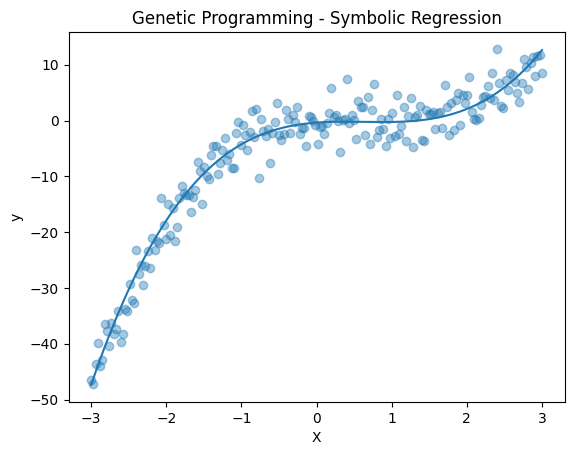

In [3]:
# Genetic Programming for Symbolic Regression

# Install gplearn library if not already installed
!pip install gplearn

import numpy as np
import matplotlib.pyplot as plt
from gplearn.genetic import SymbolicRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Step 1: Create Synthetic Dataset
# True function: y = x^3 - 2x^2 + x
# -----------------------------
np.random.seed(42)
X = np.linspace(-3, 3, 200)
y = X**3 - 2*X**2 + X + np.random.normal(0, 3, 200)

X = X.reshape(-1, 1)

# -----------------------------
# Step 2: Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# Step 3: Define Genetic Programming Model
# -----------------------------
gp_model = SymbolicRegressor(
    population_size=1000,
    generations=20,
    tournament_size=20,
    stopping_criteria=0.01,
    const_range=(-5., 5.),
    init_depth=(2, 6),
    function_set=('add', 'sub', 'mul', 'div'),
    metric='mse',
    parsimony_coefficient=0.01,
    random_state=42
)

# -----------------------------
# Step 4: Train Model
# -----------------------------
gp_model.fit(X_train, y_train)

# -----------------------------
# Step 5: Evaluate Model
# -----------------------------
y_pred = gp_model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

print("\nEvolved Expression:")
print(gp_model._program)

# -----------------------------
# Step 6: Plot Results
# -----------------------------
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_plot = gp_model.predict(X_plot)

plt.figure()
plt.scatter(X, y, alpha=0.4)
plt.plot(X_plot, y_plot)
plt.title("Genetic Programming - Symbolic Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [4]:
# Compute Posterior Probabilities Manually (Naive Bayes)

# Training dataset
# Example: Weather dataset
data = [
    ['Sunny','Hot','High','Weak','No'],
    ['Sunny','Hot','High','Strong','No'],
    ['Overcast','Hot','High','Weak','Yes'],
    ['Rain','Mild','High','Weak','Yes'],
    ['Rain','Cool','Normal','Weak','Yes'],
    ['Rain','Cool','Normal','Strong','No'],
    ['Overcast','Cool','Normal','Strong','Yes'],
    ['Sunny','Mild','High','Weak','No'],
    ['Sunny','Cool','Normal','Weak','Yes'],
    ['Rain','Mild','Normal','Weak','Yes'],
    ['Sunny','Mild','Normal','Strong','Yes'],
    ['Overcast','Mild','High','Strong','Yes'],
    ['Overcast','Hot','Normal','Weak','Yes'],
    ['Rain','Mild','High','Strong','No']
]

# Test sample
test_sample = ['Sunny','Cool','High','Strong']

# Count classes
total = len(data)
yes_count = sum(1 for row in data if row[-1]=='Yes')
no_count = sum(1 for row in data if row[-1]=='No')

# Prior probabilities
p_yes = yes_count/total
p_no = no_count/total

# Function to compute likelihood
def likelihood(feature_index, value, class_label):
    subset = [row for row in data if row[-1]==class_label]
    count = sum(1 for row in subset if row[feature_index]==value)
    return count/len(subset)

# Compute posterior for YES
posterior_yes = p_yes
for i,val in enumerate(test_sample):
    posterior_yes *= likelihood(i,val,'Yes')

# Compute posterior for NO
posterior_no = p_no
for i,val in enumerate(test_sample):
    posterior_no *= likelihood(i,val,'No')

print("Posterior Probability for Yes:", posterior_yes)
print("Posterior Probability for No:", posterior_no)

# Classification
if posterior_yes > posterior_no:
    print("Classified as: YES")
else:
    print("Classified as: NO")

Posterior Probability for Yes: 0.005291005291005291
Posterior Probability for No: 0.02057142857142857
Classified as: NO


In [ ]:
# Cross-Validation Model Evaluation

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset:", iris.target_names)

# -----------------------------
# Step 2: Define Models
# -----------------------------
models = {
    "Perceptron": Perceptron(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, random_state=42)
}

# -----------------------------
# Step 3: K-Fold Cross Validation
# -----------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("\nCross-Validation Results:\n")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    print(f"{name}")
    print("Fold Accuracies:", scores)
    print("Mean Accuracy:", round(scores.mean(), 4))
    print("Standard Deviation:", round(scores.std(), 4))
    print("----------------------------------")

Dataset: ['setosa' 'versicolor' 'virginica']

Cross-Validation Results:

Perceptron
Fold Accuracies: [0.7        0.66666667 0.93333333 0.66666667 0.63333333]
Mean Accuracy: 0.72
Standard Deviation: 0.1087
----------------------------------
Decision Tree
Fold Accuracies: [1.         0.96666667 0.93333333 0.93333333 0.93333333]
Mean Accuracy: 0.9533
Standard Deviation: 0.0267
----------------------------------
Neural Network (MLP)
Fold Accuracies: [1.         0.96666667 0.96666667 0.93333333 1.        ]
Mean Accuracy: 0.9733
Standard Deviation: 0.0249
----------------------------------


In [ ]:
# Cross-Validation Model Evaluation

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset:", iris.target_names)

# -----------------------------
# Step 2: Define Models
# -----------------------------
models = {
    "Perceptron": Perceptron(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, random_state=42)
}

# -----------------------------
# Step 3: K-Fold Cross Validation
# -----------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("\nCross-Validation Results:\n")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    print(f"{name}")
    print("Fold Accuracies:", scores)
    print("Mean Accuracy:", round(scores.mean(), 4))
    print("Standard Deviation:", round(scores.std(), 4))
    print("----------------------------------")

Dataset: ['setosa' 'versicolor' 'virginica']

Cross-Validation Results:

Perceptron
Fold Accuracies: [0.7        0.66666667 0.93333333 0.66666667 0.63333333]
Mean Accuracy: 0.72
Standard Deviation: 0.1087
----------------------------------
Decision Tree
Fold Accuracies: [1.         0.96666667 0.93333333 0.93333333 0.93333333]
Mean Accuracy: 0.9533
Standard Deviation: 0.0267
----------------------------------
Neural Network (MLP)
Fold Accuracies: [1.         0.96666667 0.96666667 0.93333333 1.        ]
Mean Accuracy: 0.9733
Standard Deviation: 0.0249
----------------------------------


In [5]:
# Bayesian Concept Learning Update

# Hypotheses space
hypotheses = ["H1", "H2", "H3"]

# Prior probabilities of hypotheses
prior = {
    "H1": 0.3,
    "H2": 0.4,
    "H3": 0.3
}

# Likelihood P(D|H) for observed data
likelihood = {
    "H1": 0.2,
    "H2": 0.6,
    "H3": 0.5
}

# Calculate Evidence P(D)
evidence = 0
for h in hypotheses:
    evidence += likelihood[h] * prior[h]

# Compute Posterior probabilities P(H|D)
posterior = {}

for h in hypotheses:
    posterior[h] = (likelihood[h] * prior[h]) / evidence

# Display results
print("Posterior Probabilities after Bayesian Update:\n")

for h in hypotheses:
    print(h, ":", posterior[h])

Posterior Probabilities after Bayesian Update:

H1 : 0.13333333333333333
H2 : 0.5333333333333333
H3 : 0.33333333333333337


In [6]:
# Logistic Regression Implementation

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Slope (Coefficient): 10.000000000000005
Intercept: -2.1316282072803006e-14


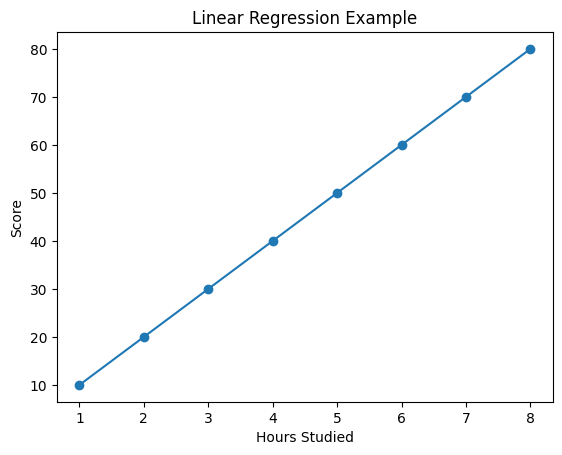

In [7]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8],
    'Score': [10, 20, 30, 40, 50, 60, 70, 80]
}

# Convert dataset into DataFrame
df = pd.DataFrame(data)

# Independent variable (X) and dependent variable (y)
X = df[['Hours']]
y = df['Score']

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Display slope and intercept
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

# Plot the data and regression line
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Linear Regression Example")
plt.show()

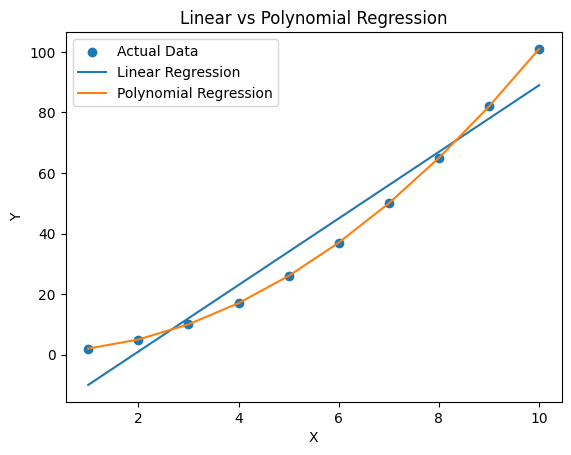

Linear Regression Predictions:
[-10.   1.  12.  23.  34.  45.  56.  67.  78.  89.]

Polynomial Regression Predictions:
[  2.   5.  10.  17.  26.  37.  50.  65.  82. 101.]


In [8]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Sample dataset
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2,5,10,17,26,37,50,65,82,101])

# -------- Linear Regression --------
linear_model = LinearRegression()
linear_model.fit(X,y)
y_linear_pred = linear_model.predict(X)

# -------- Polynomial Regression --------
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly,y)
y_poly_pred = poly_model.predict(X_poly)

# -------- Plot comparison --------
plt.scatter(X,y,label="Actual Data")
plt.plot(X,y_linear_pred,label="Linear Regression")
plt.plot(X,y_poly_pred,label="Polynomial Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

# Print results
print("Linear Regression Predictions:")
print(y_linear_pred)

print("\nPolynomial Regression Predictions:")
print(y_poly_pred)

In [9]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()

X = data.data      # Features
y = data.target    # Target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Create Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[16  0  0]
 [ 0 18  0]
 [ 0  0 11]]

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        11

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [10]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
iris = load_iris()

X = iris.data       # Features
y = iris.target     # Labels

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Create model (KNN Classifier)
model = KNeighborsClassifier(n_neighbors=3)

# Train model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Predict new sample
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print("\nPredicted class:", iris.target_names[prediction][0])

Accuracy: 0.9777777777777777

Confusion Matrix:
[[14  0  0]
 [ 0 18  0]
 [ 0  1 12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.95      1.00      0.97        18
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45


Predicted class: setosa


In [12]:
# Install pgmpy (run once in Google Colab)
!pip install pgmpy

# Import libraries
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the Bayesian Network structure
# Example: Rain → Traffic ← Accident
model = DiscreteBayesianNetwork([('Rain', 'Traffic'),
                         ('Accident', 'Traffic')])

# Define Conditional Probability Distributions (CPD)

cpd_rain = TabularCPD(variable='Rain', variable_card=2,
                      values=[[0.7], [0.3]])

cpd_accident = TabularCPD(variable='Accident', variable_card=2,
                          values=[[0.8], [0.2]])

cpd_traffic = TabularCPD(variable='Traffic', variable_card=2,
                         values=[[0.9, 0.6, 0.7, 0.1],
                                 [0.1, 0.4, 0.3, 0.9]],
                         evidence=['Rain', 'Accident'],
                         evidence_card=[2, 2])

# Add CPDs to the model
model.add_cpds(cpd_rain, cpd_accident, cpd_traffic)

# Check model validity
print("Model is valid:", model.check_model())

# Perform inference
inference = VariableElimination(model)

# Query probability of Traffic given Rain
result = inference.query(variables=['Traffic'], evidence={'Rain':1})

print("\nInference Result:")
print(result)

Model is valid: True

Inference Result:
+------------+----------------+
| Traffic    |   phi(Traffic) |
+============+================+
| Traffic(0) |         0.5800 |
+------------+----------------+
| Traffic(1) |         0.4200 |
+------------+----------------+


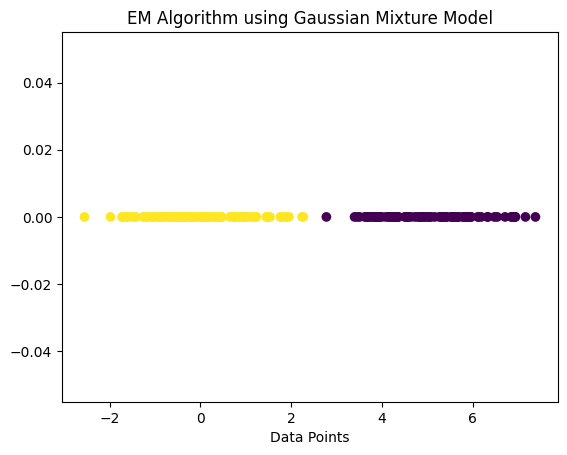

Means: [[5.06646752]
 [0.05404566]]
Variances: [[[1.11854073]]

 [[1.01670263]]]
Weights: [0.5021255 0.4978745]


In [13]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Generate sample dataset
np.random.seed(0)

data1 = np.random.normal(0, 1, 100)
data2 = np.random.normal(5, 1, 100)

X = np.concatenate([data1, data2]).reshape(-1,1)

# Apply EM algorithm using Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=0)

# Train model
gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

# Plot result
plt.scatter(X, np.zeros_like(X), c=labels)
plt.title("EM Algorithm using Gaussian Mixture Model")
plt.xlabel("Data Points")
plt.show()

# Print model parameters
print("Means:", gmm.means_)
print("Variances:", gmm.covariances_)
print("Weights:", gmm.weights_)

Estimated Mean: 6.5
Estimated Variance: 2.25
Estimated Standard Deviation: 1.5


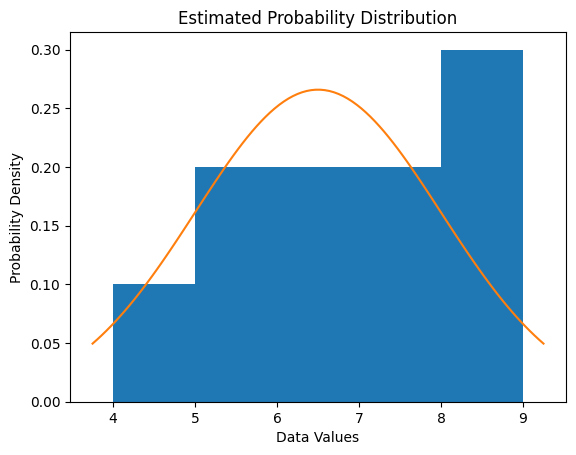

In [14]:
# Import library
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Sample dataset
data = np.array([5, 7, 8, 6, 9, 5, 4, 7, 8, 6])

# Estimate parameters
mean = np.mean(data)
variance = np.var(data)
std_dev = np.std(data)

print("Estimated Mean:", mean)
print("Estimated Variance:", variance)
print("Estimated Standard Deviation:", std_dev)

# Plot histogram and estimated normal distribution
plt.hist(data, bins=5, density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)

plt.plot(x, p)
plt.title("Estimated Probability Distribution")
plt.xlabel("Data Values")
plt.ylabel("Probability Density")
plt.show()

In [15]:
# Import libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

# Predict test data
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict new sample
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = knn.predict(sample)

print("\nPredicted Class:", iris.target_names[prediction][0])


Accuracy: 0.9777777777777777

Confusion Matrix:
[[14  0  0]
 [ 0 18  0]
 [ 0  1 12]]

Predicted Class: setosa


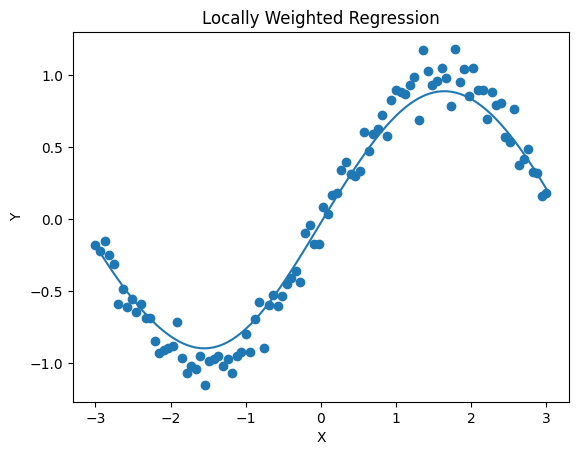

In [16]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.1, 100)

# Bandwidth parameter
tau = 0.5

# Locally Weighted Regression function
def lw_regression(x_query, X, y, tau):
    weights = np.exp(-(X - x_query)**2 / (2 * tau**2))
    W = np.diag(weights)

    X_mat = np.vstack((np.ones(len(X)), X)).T
    theta = np.linalg.pinv(X_mat.T @ W @ X_mat) @ X_mat.T @ W @ y

    return theta[0] + theta[1] * x_query

# Predict values
y_pred = np.array([lw_regression(x, X, y, tau) for x in X])

# Plot results
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Locally Weighted Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [17]:
# Import libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create k-NN model
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

# Predict the test data
y_pred = knn.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Predict a new flower
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = knn.predict(sample)

print("\nPredicted Flower:", iris.target_names[prediction][0])

Accuracy: 1.0

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Predicted Flower: setosa


In [18]:
# Import libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Create RBF Network model (SVM with RBF kernel)
model = SVC(kernel='rbf')

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict new sample
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print("\nPredicted Class:", iris.target_names[prediction][0])

Accuracy: 0.9777777777777777

Confusion Matrix:
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]

Predicted Class: setosa


In [19]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sample credit dataset
data = {
    'Income': [50000, 60000, 30000, 80000, 20000, 70000, 40000, 90000],
    'Age': [25, 35, 45, 30, 50, 40, 28, 33],
    'Loan': [20000, 25000, 15000, 30000, 10000, 27000, 18000, 35000],
    'CreditScore': [1, 1, 0, 1, 0, 1, 0, 1]   # 1 = Good, 0 = Bad
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Features and target
X = df[['Income', 'Age', 'Loan']]
y = df['CreditScore']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Predict new customer
new_customer = [[55000, 29, 22000]]
prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("\nCredit Status: Good Credit")
else:
    print("\nCredit Status: Bad Credit")

Accuracy: 0.6666666666666666

Confusion Matrix:
 [[1 1]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


Credit Status: Good Credit


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [22]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sample credit dataset
data = {
    'Income': [50000, 60000, 30000, 80000, 20000, 70000, 40000, 90000],
    'Age': [25, 35, 45, 30, 50, 40, 28, 33],
    'Loan': [20000, 25000, 15000, 30000, 10000, 27000, 18000, 35000],
    'CreditScore': [1, 1, 0, 1, 0, 1, 0, 1]   # 1 = Good, 0 = Bad
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Features and target
X = df[['Income', 'Age', 'Loan']]
y = df['CreditScore']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Predict new customer
new_customer = [[55000, 29, 22000]]
prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("\nCredit Status: Good Credit")
else:
    print("\nCredit Status: Bad Credit")

Accuracy: 0.6666666666666666

Confusion Matrix:
 [[1 1]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


Credit Status: Good Credit


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [23]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sample dataset
data = {
    'EngineSize': [1.0, 1.2, 1.5, 2.0, 2.2, 1.8, 2.5, 3.0],
    'Horsepower': [70, 80, 100, 150, 160, 140, 200, 250],
    'Age': [5, 4, 3, 2, 1, 3, 2, 1],
    'Price': [5000, 6000, 8000, 12000, 15000, 11000, 20000, 25000]
}

# Convert dataset into DataFrame
df = pd.DataFrame(data)

# Features and target
X = df[['EngineSize', 'Horsepower', 'Age']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict prices
y_pred = model.predict(X_test)

# Evaluate model
print("Predicted Prices:", y_pred)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict price of a new car
new_car = [[2.0, 150, 2]]
predicted_price = model.predict(new_car)

print("\nPredicted Car Price:", predicted_price[0])

Predicted Prices: [23500.         11166.66666667  7000.        ]
Mean Squared Error: 7759259.259259247

Predicted Car Price: 12666.666666666657


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
# Import libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Create RBF Network model (SVM with RBF kernel)
model = SVC(kernel='rbf')

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict new sample
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print("\nPredicted Class:", iris.target_names[prediction][0])

Accuracy: 0.9777777777777777

Confusion Matrix:
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]

Predicted Class: setosa


In [25]:
# Import libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create k-NN model
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

# Predict the test data
y_pred = knn.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Predict a new flower
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = knn.predict(sample)

print("\nPredicted Flower:", iris.target_names[prediction][0])

Accuracy: 1.0

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Predicted Flower: setosa


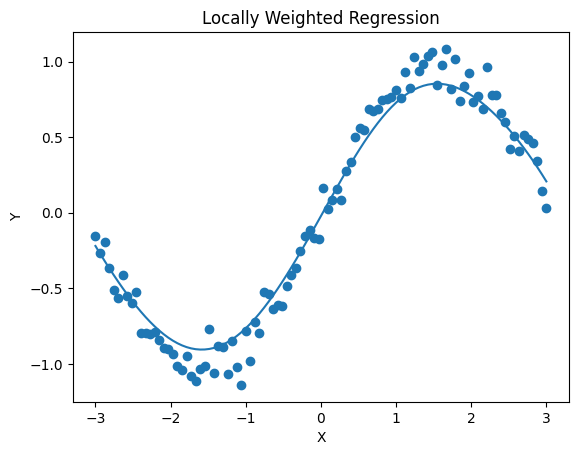

In [26]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset
X = np.linspace(-3, 3, 100)
y = np.sin(X) + np.random.normal(0, 0.1, 100)

# Bandwidth parameter
tau = 0.5

# Locally Weighted Regression function
def lw_regression(x_query, X, y, tau):
    weights = np.exp(-(X - x_query)**2 / (2 * tau**2))
    W = np.diag(weights)

    X_mat = np.vstack((np.ones(len(X)), X)).T
    theta = np.linalg.pinv(X_mat.T @ W @ X_mat) @ X_mat.T @ W @ y

    return theta[0] + theta[1] * x_query

# Predict values
y_pred = np.array([lw_regression(x, X, y, tau) for x in X])

# Plot results
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Locally Weighted Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [27]:
# Import libraries
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

# Predict test data
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict new sample
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = knn.predict(sample)

print("\nPredicted Class:", iris.target_names[prediction][0])

Accuracy: 0.9777777777777777

Confusion Matrix:
[[14  0  0]
 [ 0 18  0]
 [ 0  1 12]]

Predicted Class: setosa


Estimated Mean: 6.5
Estimated Variance: 2.25
Estimated Standard Deviation: 1.5


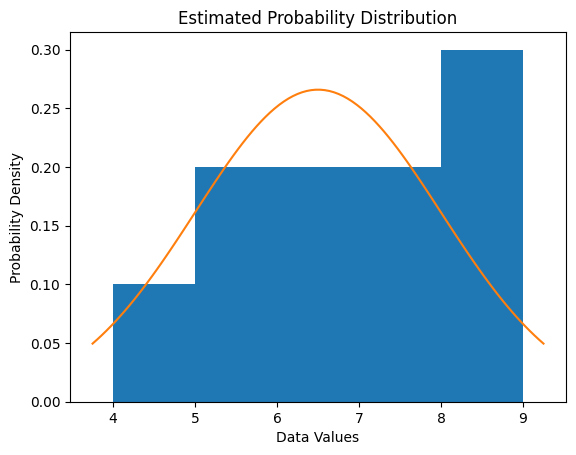

In [28]:
# Import library
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Sample dataset
data = np.array([5, 7, 8, 6, 9, 5, 4, 7, 8, 6])

# Estimate parameters
mean = np.mean(data)
variance = np.var(data)
std_dev = np.std(data)

print("Estimated Mean:", mean)
print("Estimated Variance:", variance)
print("Estimated Standard Deviation:", std_dev)

# Plot histogram and estimated normal distribution
plt.hist(data, bins=5, density=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)

plt.plot(x, p)
plt.title("Estimated Probability Distribution")
plt.xlabel("Data Values")
plt.ylabel("Probability Density")
plt.show()

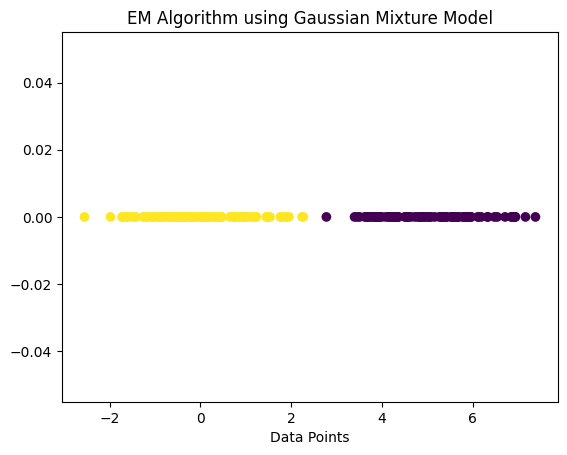

Means: [[5.06646752]
 [0.05404566]]
Variances: [[[1.11854073]]

 [[1.01670263]]]
Weights: [0.5021255 0.4978745]


In [29]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Generate sample dataset
np.random.seed(0)

data1 = np.random.normal(0, 1, 100)
data2 = np.random.normal(5, 1, 100)

X = np.concatenate([data1, data2]).reshape(-1,1)

# Apply EM algorithm using Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=0)

# Train model
gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

# Plot result
plt.scatter(X, np.zeros_like(X), c=labels)
plt.title("EM Algorithm using Gaussian Mixture Model")
plt.xlabel("Data Points")
plt.show()

# Print model parameters
print("Means:", gmm.means_)
print("Variances:", gmm.covariances_)
print("Weights:", gmm.weights_)

In [33]:
# Install pgmpy (run once in Google Colab)
!pip install pgmpy

# Import libraries
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Define the Bayesian Network structure
# Example: Rain → Traffic ← Accident
model = DiscreteBayesianNetwork([('Rain', 'Traffic'),
                         ('Accident', 'Traffic')])

# Define Conditional Probability Distributions (CPD)

cpd_rain = TabularCPD(variable='Rain', variable_card=2,
                      values=[[0.7], [0.3]])

cpd_accident = TabularCPD(variable='Accident', variable_card=2,
                          values=[[0.8], [0.2]])

cpd_traffic = TabularCPD(variable='Traffic', variable_card=2,
                         values=[[0.9, 0.6, 0.7, 0.1],
                                 [0.1, 0.4, 0.3, 0.9]],
                         evidence=['Rain', 'Accident'],
                         evidence_card=[2, 2])

# Add CPDs to the model
model.add_cpds(cpd_rain, cpd_accident, cpd_traffic)

# Check model validity
print("Model is valid:", model.check_model())

# Perform inference
inference = VariableElimination(model)

# Query probability of Traffic given Rain
result = inference.query(variables=['Traffic'], evidence={'Rain':1})

print("\nInference Result:")
print(result)

Model is valid: True

Inference Result:
+------------+----------------+
| Traffic    |   phi(Traffic) |
+============+================+
| Traffic(0) |         0.5800 |
+------------+----------------+
| Traffic(1) |         0.4200 |
+------------+----------------+


In [31]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
iris = load_iris()

X = iris.data       # Features
y = iris.target     # Labels

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Create model (KNN Classifier)
model = KNeighborsClassifier(n_neighbors=3)

# Train model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Predict new sample
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print("\nPredicted class:", iris.target_names[prediction][0])

Accuracy: 0.9777777777777777

Confusion Matrix:
[[14  0  0]
 [ 0 18  0]
 [ 0  1 12]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.95      1.00      0.97        18
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45


Predicted class: setosa


In [34]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()

X = data.data      # Features
y = data.target    # Target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Create Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[16  0  0]
 [ 0 18  0]
 [ 0  0 11]]

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        11

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



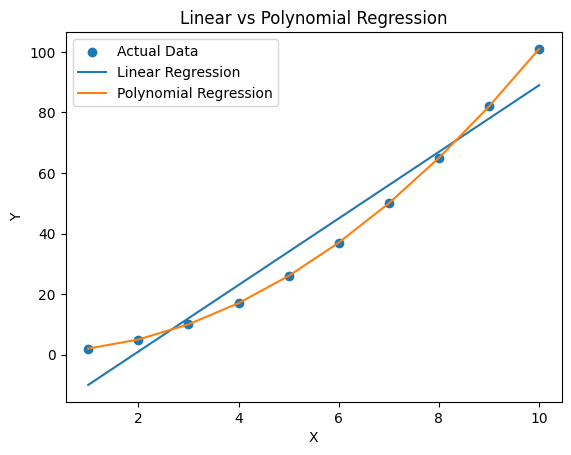

Linear Regression Predictions:
[-10.   1.  12.  23.  34.  45.  56.  67.  78.  89.]

Polynomial Regression Predictions:
[  2.   5.  10.  17.  26.  37.  50.  65.  82. 101.]


In [35]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Sample dataset
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y = np.array([2,5,10,17,26,37,50,65,82,101])

# -------- Linear Regression --------
linear_model = LinearRegression()
linear_model.fit(X,y)
y_linear_pred = linear_model.predict(X)

# -------- Polynomial Regression --------
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly,y)
y_poly_pred = poly_model.predict(X_poly)

# -------- Plot comparison --------
plt.scatter(X,y,label="Actual Data")
plt.plot(X,y_linear_pred,label="Linear Regression")
plt.plot(X,y_poly_pred,label="Polynomial Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

# Print results
print("Linear Regression Predictions:")
print(y_linear_pred)

print("\nPolynomial Regression Predictions:")
print(y_poly_pred)

Slope (Coefficient): 10.000000000000005
Intercept: -2.1316282072803006e-14


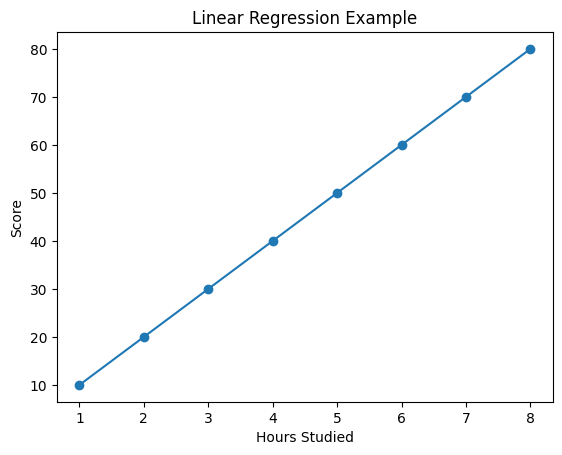

In [36]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8],
    'Score': [10, 20, 30, 40, 50, 60, 70, 80]
}

# Convert dataset into DataFrame
df = pd.DataFrame(data)

# Independent variable (X) and dependent variable (y)
X = df[['Hours']]
y = df['Score']

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Display slope and intercept
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

# Plot the data and regression line
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Linear Regression Example")
plt.show()

In [37]:
# Logistic Regression Implementation

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [38]:
# Logistic Regression Implementation

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [39]:
# Bayesian Concept Learning Update

# Hypotheses space
hypotheses = ["H1", "H2", "H3"]

# Prior probabilities of hypotheses
prior = {
    "H1": 0.3,
    "H2": 0.4,
    "H3": 0.3
}

# Likelihood P(D|H) for observed data
likelihood = {
    "H1": 0.2,
    "H2": 0.6,
    "H3": 0.5
}

# Calculate Evidence P(D)
evidence = 0
for h in hypotheses:
    evidence += likelihood[h] * prior[h]

# Compute Posterior probabilities P(H|D)
posterior = {}

for h in hypotheses:
    posterior[h] = (likelihood[h] * prior[h]) / evidence

# Display results
print("Posterior Probabilities after Bayesian Update:\n")

for h in hypotheses:
    print(h, ":", posterior[h])

Posterior Probabilities after Bayesian Update:

H1 : 0.13333333333333333
H2 : 0.5333333333333333
H3 : 0.33333333333333337


In [40]:
# Compute Posterior Probabilities Manually (Naive Bayes)

# Training dataset
# Example: Weather dataset
data = [
    ['Sunny','Hot','High','Weak','No'],
    ['Sunny','Hot','High','Strong','No'],
    ['Overcast','Hot','High','Weak','Yes'],
    ['Rain','Mild','High','Weak','Yes'],
    ['Rain','Cool','Normal','Weak','Yes'],
    ['Rain','Cool','Normal','Strong','No'],
    ['Overcast','Cool','Normal','Strong','Yes'],
    ['Sunny','Mild','High','Weak','No'],
    ['Sunny','Cool','Normal','Weak','Yes'],
    ['Rain','Mild','Normal','Weak','Yes'],
    ['Sunny','Mild','Normal','Strong','Yes'],
    ['Overcast','Mild','High','Strong','Yes'],
    ['Overcast','Hot','Normal','Weak','Yes'],
    ['Rain','Mild','High','Strong','No']
]

# Test sample
test_sample = ['Sunny','Cool','High','Strong']

# Count classes
total = len(data)
yes_count = sum(1 for row in data if row[-1]=='Yes')
no_count = sum(1 for row in data if row[-1]=='No')

# Prior probabilities
p_yes = yes_count/total
p_no = no_count/total

# Function to compute likelihood
def likelihood(feature_index, value, class_label):
    subset = [row for row in data if row[-1]==class_label]
    count = sum(1 for row in subset if row[feature_index]==value)
    return count/len(subset)

# Compute posterior for YES
posterior_yes = p_yes
for i,val in enumerate(test_sample):
    posterior_yes *= likelihood(i,val,'Yes')

# Compute posterior for NO
posterior_no = p_no
for i,val in enumerate(test_sample):
    posterior_no *= likelihood(i,val,'No')

print("Posterior Probability for Yes:", posterior_yes)
print("Posterior Probability for No:", posterior_no)

# Classification
if posterior_yes > posterior_no:
    print("Classified as: YES")
else:
    print("Classified as: NO")

Posterior Probability for Yes: 0.005291005291005291
Posterior Probability for No: 0.02057142857142857
Classified as: NO


In [42]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sample mobile dataset
data = {
    'RAM': [4, 6, 8, 3, 12, 8, 6, 4],
    'Storage': [64, 128, 128, 32, 256, 256, 128, 64],
    'Battery': [4000, 4500, 5000, 3500, 6000, 5500, 4800, 4200],
    'Price': [15000, 20000, 25000, 12000, 40000, 35000, 22000, 16000]
}

# Convert dataset into DataFrame
df = pd.DataFrame(data)

# Features and target
X = df[['RAM', 'Storage', 'Battery']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict mobile prices
y_pred = model.predict(X_test)

# Evaluation
print("Predicted Prices:", y_pred)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict price for a new mobile
new_mobile = [[8, 128, 5000]]
predicted_price = model.predict(new_mobile)

print("\nPredicted Mobile Price:", predicted_price[0])

Predicted Prices: [23050.024888   25508.71080139 22802.14036834]
Mean Squared Error: 3071109.8629256133

Predicted Mobile Price: 25508.71080139373


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [43]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Sample sales dataset
data = {
    'Month': [1,2,3,4,5,6,7,8,9,10],
    'Advertising': [200,220,250,270,300,320,350,370,400,420],
    'Sales': [400,420,450,480,500,520,550,580,600,620]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Features and target
X = df[['Month','Advertising']]
y = df['Sales']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

# Predict sales
y_pred = model.predict(X_test)

# Evaluate model
print("Predicted Sales:", y_pred)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict future sales
future = [[11,450]]   # Month 11 with advertising cost
future_sales = model.predict(future)

print("\nPredicted Future Sales:", future_sales[0])

Predicted Sales: [447.2 591.8 504.3]
Mean Squared Error: 31.1900000000003

Predicted Future Sales: 601.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [45]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC()
}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(name, "Accuracy:", accuracy)

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0
KNN Accuracy: 1.0
SVM Accuracy: 1.0


In [46]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Sample bank loan dataset
data = {
    'Income': [25000, 40000, 50000, 60000, 35000, 80000, 120000, 70000],
    'Age': [25, 35, 45, 30, 50, 40, 55, 33],
    'LoanAmount': [10000, 20000, 25000, 30000, 15000, 40000, 50000, 35000],
    'LoanApproved': [0, 1, 1, 1, 0, 1, 1, 1]   # 1 = Approved, 0 = Not Approved
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Features and target
X = df[['Income', 'Age', 'LoanAmount']]
y = df['LoanApproved']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Train Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Predict loan approval for a new applicant
new_applicant = [[45000, 32, 20000]]
prediction = model.predict(new_applicant)

if prediction[0] == 1:
    print("\nLoan Status: Approved")
else:
    print("\nLoan Status: Not Approved")


Accuracy: 0.6666666666666666

Confusion Matrix:
 [[0 0]
 [1 2]]

Loan Status: Not Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [47]:
# Import NumPy
import numpy as np

# Generate random dataset (100 samples, 4 features)
np.random.seed(0)
X = np.random.rand(100, 4)

# Generate random target values
y = np.random.randint(0, 2, 100)

# Number of samples
n_samples = X.shape[0]

# Shuffle indices
indices = np.random.permutation(n_samples)

# 80% training and 20% testing
train_size = int(0.8 * n_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Advanced NumPy indexing
X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

# Display results
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nFirst 5 Training Samples:\n", X_train[:5])
print("\nFirst 5 Testing Samples:\n", X_test[:5])

Training Data Shape: (80, 4)
Testing Data Shape: (20, 4)

First 5 Training Samples:
 [[0.5759465  0.9292962  0.31856895 0.66741038]
 [0.97861834 0.79915856 0.46147936 0.78052918]
 [0.49739137 0.63947252 0.36858461 0.13690027]
 [0.4236548  0.64589411 0.43758721 0.891773  ]
 [0.66991655 0.78515291 0.28173011 0.58641017]]

First 5 Testing Samples:
 [[0.35536885 0.35670689 0.0163285  0.18523233]
 [0.0202184  0.83261985 0.77815675 0.87001215]
 [0.97676109 0.60484552 0.73926358 0.03918779]
 [0.82211773 0.18984791 0.51131898 0.22431703]
 [0.40724117 0.23223414 0.13248763 0.05342718]]


In [48]:
# Apply NumPy filtering to extract data subsets and compute summary statistics

import numpy as np

# Step 1: Generate random dataset
np.random.seed(0)
data = np.random.randint(10, 100, size=(20, 3))   # 20 rows, 3 columns

print("Original Dataset:\n")
print(data)

# Step 2: Filter rows where first column value > 50
filtered_data = data[data[:,0] > 50]

print("\nFiltered Data (First column > 50):\n")
print(filtered_data)

# Step 3: Compute summary statistics
mean_val = np.mean(filtered_data, axis=0)
median_val = np.median(filtered_data, axis=0)
std_val = np.std(filtered_data, axis=0)
min_val = np.min(filtered_data, axis=0)
max_val = np.max(filtered_data, axis=0)

print("\nSummary Statistics (Column-wise):\n")

print("Mean:", mean_val)
print("Median:", median_val)
print("Standard Deviation:", std_val)
print("Minimum:", min_val)
print("Maximum:", max_val)

Original Dataset:

[[54 57 74]
 [77 77 19]
 [93 31 46]
 [97 80 98]
 [98 22 68]
 [75 49 97]
 [56 98 91]
 [47 35 87]
 [82 19 30]
 [90 79 89]
 [57 74 92]
 [98 59 39]
 [29 29 24]
 [49 42 75]
 [19 67 42]
 [41 84 33]
 [45 85 65]
 [38 44 10]
 [10 46 63]
 [15 48 27]]

Filtered Data (First column > 50):

[[54 57 74]
 [77 77 19]
 [93 31 46]
 [97 80 98]
 [98 22 68]
 [75 49 97]
 [56 98 91]
 [82 19 30]
 [90 79 89]
 [57 74 92]
 [98 59 39]]

Summary Statistics (Column-wise):

Mean: [79.72727273 58.63636364 67.54545455]
Median: [82. 59. 74.]
Standard Deviation: [16.58088115 24.80202604 27.78280579]
Minimum: [54 19 19]
Maximum: [98 98 98]


In [49]:
# Aggregate NumPy array data and export results to CSV

import numpy as np
import pandas as pd

# Step 1: Generate sample NumPy array data
np.random.seed(0)
data = np.random.randint(10, 100, size=(10, 4))

print("Original Data:\n", data)

# Step 2: Aggregate the data
sum_val = np.sum(data, axis=0)
mean_val = np.mean(data, axis=0)
max_val = np.max(data, axis=0)
min_val = np.min(data, axis=0)

# Step 3: Store results in dictionary
results = {
    "Sum": sum_val,
    "Mean": mean_val,
    "Max": max_val,
    "Min": min_val
}

# Convert to DataFrame
df = pd.DataFrame(results)

print("\nAggregated Results:\n")
print(df)

# Step 4: Export results to CSV
df.to_csv("aggregated_results.csv", index=False)

print("\nResults exported successfully to 'aggregated_results.csv'")

Original Data:
 [[54 57 74 77]
 [77 19 93 31]
 [46 97 80 98]
 [98 22 68 75]
 [49 97 56 98]
 [91 47 35 87]
 [82 19 30 90]
 [79 89 57 74]
 [92 98 59 39]
 [29 29 24 49]]

Aggregated Results:

   Sum  Mean  Max  Min
0  697  69.7   98   29
1  574  57.4   98   19
2  576  57.6   93   24
3  718  71.8   98   31

Results exported successfully to 'aggregated_results.csv'


Saving data.csv to data.csv
First 5 rows of the dataset:
   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  169 non-null    int64  
 1   Pulse     169 non-null    int64  
 2   Maxpulse  169 non-null    int64  
 3   Calories  164 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 5.4 KB
None

Statistical Summary:
         Duration       Pulse    Maxpulse     Calories
count  169.000000  169.000000  169.000000   164.000000
mean    63.846154  107.461538  134.047337   375.790244
std     42.299949   14.510259   16.450434   266.379919
min     15.000000   80.000000  100.000000    50.3000

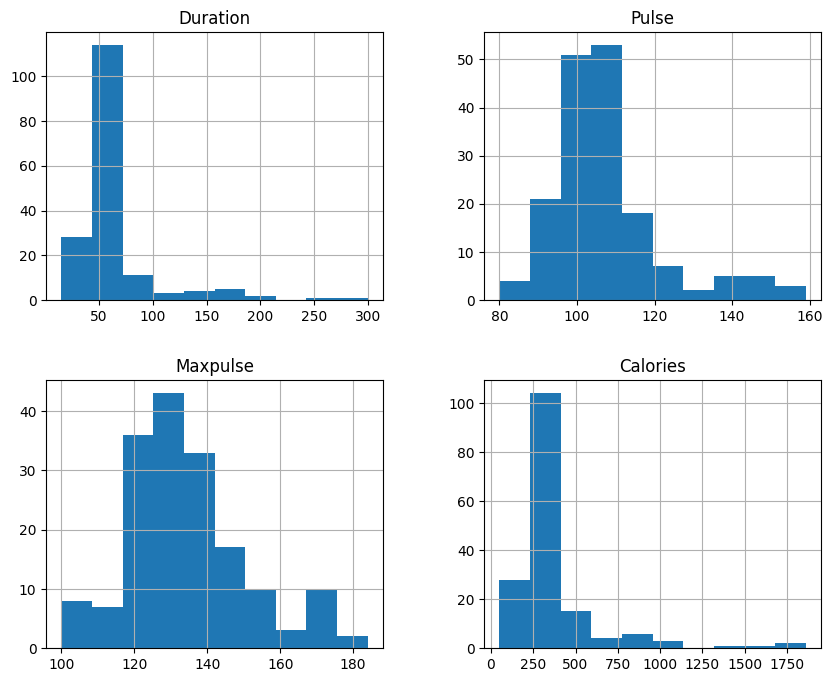

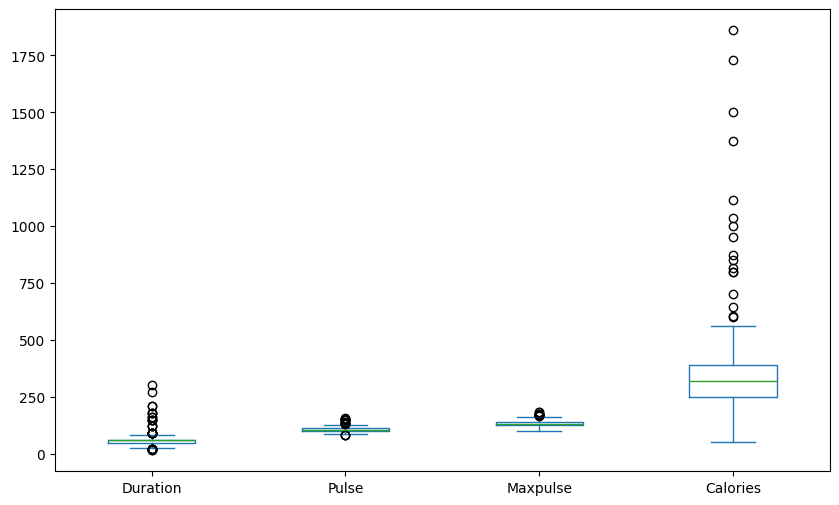

In [50]:
# Load CSV and Perform Exploratory Data Analysis (EDA)

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Upload CSV file in Google Colab
from google.colab import files
uploaded = files.upload()

# Step 2: Load the CSV file
df = pd.read_csv(list(uploaded.keys())[0])

# Step 3: Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Step 4: Dataset information
print("\nDataset Information:")
print(df.info())

# Step 5: Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Step 6: Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 7: Correlation matrix
print("\nCorrelation Matrix:")
print(df.corr())

# Step 8: Plot histogram for numerical features
df.hist(figsize=(10,8))
plt.show()

# Step 9: Boxplot for detecting outliers
df.plot(kind='box', figsize=(10,6))
plt.show()

In [51]:
# Merge multiple Pandas DataFrames and apply advanced indexing

import pandas as pd

# Step 1: Create first DataFrame
data1 = {
    "ID": [1, 2, 3, 4],
    "Name": ["Alice", "Bob", "Charlie", "David"],
    "Age": [22, 24, 23, 25]
}

df1 = pd.DataFrame(data1)
print("DataFrame 1:")
print(df1)

# Step 2: Create second DataFrame
data2 = {
    "ID": [1, 2, 3, 4],
    "Department": ["IT", "HR", "Finance", "Marketing"],
    "Salary": [50000, 45000, 55000, 60000]
}

df2 = pd.DataFrame(data2)
print("\nDataFrame 2:")
print(df2)

# Step 3: Merge DataFrames
merged_df = pd.merge(df1, df2, on="ID")
print("\nMerged DataFrame:")
print(merged_df)

# Step 4: Advanced Indexing Examples

# Select rows where Salary > 50000
high_salary = merged_df[merged_df["Salary"] > 50000]
print("\nEmployees with Salary > 50000:")
print(high_salary)

# Select specific rows and columns using loc
loc_example = merged_df.loc[0:2, ["Name", "Salary"]]
print("\nUsing loc:")
print(loc_example)

# Select rows and columns using iloc
iloc_example = merged_df.iloc[1:3, 1:4]
print("\nUsing iloc:")
print(iloc_example)

DataFrame 1:
   ID     Name  Age
0   1    Alice   22
1   2      Bob   24
2   3  Charlie   23
3   4    David   25

DataFrame 2:
   ID Department  Salary
0   1         IT   50000
1   2         HR   45000
2   3    Finance   55000
3   4  Marketing   60000

Merged DataFrame:
   ID     Name  Age Department  Salary
0   1    Alice   22         IT   50000
1   2      Bob   24         HR   45000
2   3  Charlie   23    Finance   55000
3   4    David   25  Marketing   60000

Employees with Salary > 50000:
   ID     Name  Age Department  Salary
2   3  Charlie   23    Finance   55000
3   4    David   25  Marketing   60000

Using loc:
      Name  Salary
0    Alice   50000
1      Bob   45000
2  Charlie   55000

Using iloc:
      Name  Age Department
1      Bob   24         HR
2  Charlie   23    Finance


In [52]:
# Read and Write datasets with Pandas and perform GroupBy aggregation

import pandas as pd

# Step 1: Upload CSV file
from google.colab import files
uploaded = files.upload()

# Step 2: Read dataset
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Preview:")
print(df.head())

# Step 3: Perform GroupBy aggregation
# Example: group by a column and calculate mean
grouped = df.groupby(df.columns[0]).mean()

print("\nGroupBy Aggregation Result:")
print(grouped)

# Step 4: Save results to a new CSV file
grouped.to_csv("groupby_results.csv")

print("\nAggregated results saved as groupby_results.csv")

# Step 5: Download the result file
files.download("groupby_results.csv")

Saving data.csv to data (1).csv
Dataset Preview:
   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0

GroupBy Aggregation Result:
               Pulse    Maxpulse     Calories
Duration                                     
15        102.000000  119.500000    87.350000
20        125.000000  146.000000   151.600000
25        152.000000  168.000000   244.200000
30        109.812500  137.000000   192.125000
45        107.485714  133.228571   273.236364
60        106.126582  132.860759   339.675000
75        122.500000  150.000000   325.400000
80        123.000000  146.000000   643.100000
90         93.750000  116.375000   541.800000
120       100.000000  139.000000   666.833333
150       101.500000  130.250000   939.400000
160       109.500000  136.000000   943.700000
180        93.666667  125.666667   733.60000

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Original DataFrame:
      Name  Age  Score
0    Alice   22     85
1      Bob   25     90
2  Charlie   23     78
3    David   24     88
4      Eva   26     92

Filtered Data (Score > 85):
    Name  Age  Score
1    Bob   25     90
3  David   24     88
4    Eva   26     92

Sorted DataFrame (by Score):
      Name  Age  Score
4      Eva   26     92
1      Bob   25     90
3    David   24     88
0    Alice   22     85
2  Charlie   23     78


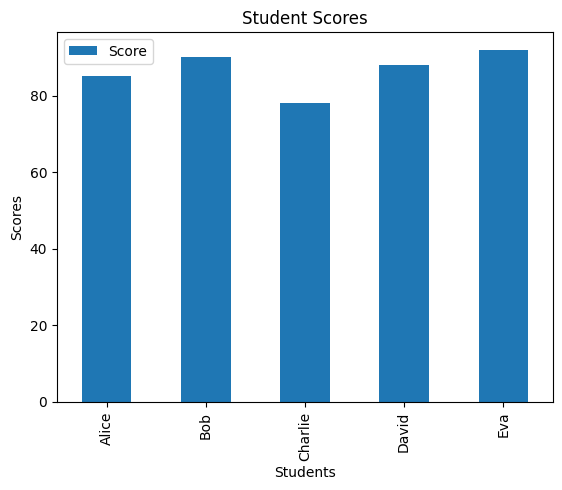

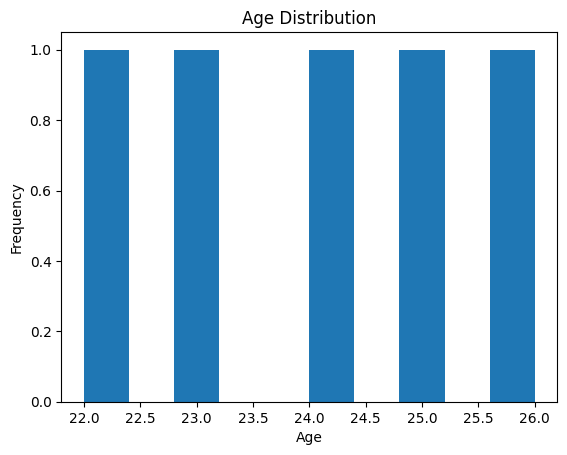

In [53]:
# Filter and Sort DataFrames; Generate basic plots

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create sample dataset
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Eva"],
    "Age": [22, 25, 23, 24, 26],
    "Score": [85, 90, 78, 88, 92]
}

df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)

# Step 2: Filter data (Score > 85)
filtered_df = df[df["Score"] > 85]

print("\nFiltered Data (Score > 85):")
print(filtered_df)

# Step 3: Sort data by Score
sorted_df = df.sort_values(by="Score", ascending=False)

print("\nSorted DataFrame (by Score):")
print(sorted_df)

# Step 4: Plot Score values
df.plot(x="Name", y="Score", kind="bar", title="Student Scores")

plt.xlabel("Students")
plt.ylabel("Scores")
plt.show()

# Step 5: Plot Age distribution
df["Age"].plot(kind="hist", title="Age Distribution")

plt.xlabel("Age")
plt.show()

## Google Colab is available in VS Code!
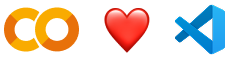

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## 🎁 Free Pro Plan for Gemini & Colab for US College Students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research, and innovative projects, backed by Colab’s dedicated high-compute resources for data science and machine learning.

Get the Gemini free offer at [gemini.google/students](https://gemini.google/students?utm_source=colab&utm_medium=banner&utm_campaign=students_xpa_us-colab-banner).  
Get the Colab free offer at [colab.research.google.com/signup](https://colab.research.google.com/signup).  
Terms Apply.

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  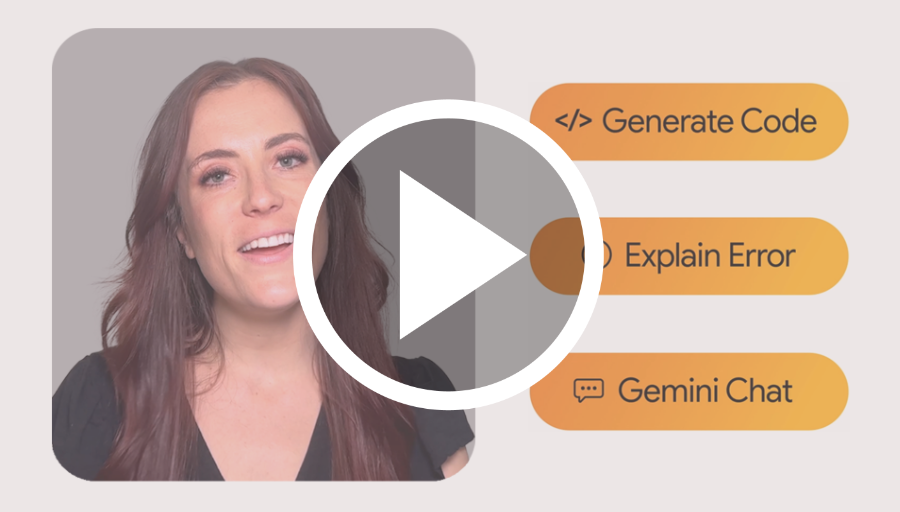
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

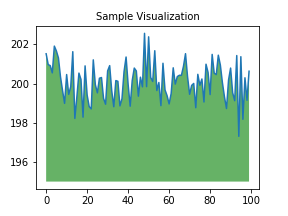

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)


In [ ]:
import pandas
mydataset ={
    'cars':["bmw","volvo","ford"],
    'passings':[3,7,2]
}
myvar = pandas.DataFrame(mydataset)
print(myvar)

    cars  passings
0    bmw         3
1  volvo         7
2   ford         2


In [ ]:
import pandas as pd
a =[1,7,2]
myvar =pd.Series(a)
print(myvar)

0    1
1    7
2    2
dtype: int64


In [ ]:
import pandas as pd
a = [1,7,2]
myvar = pd.Series(a, index =["x","y","z"])
print(myvar)

x    1
y    7
z    2
dtype: int64


In [ ]:
import pandas as pd
data = {
"calories": [420, 380, 390],
"duration": [50, 40, 45]
}
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)

   calories  duration
0       420        50
1       380        40
2       390        45


In [ ]:
import pandas as pd
df = pd.read_csv('data.csv')
print(df.to_string())

SyntaxError: invalid non-printable character U+00A0 (1961513763.py, line 1)